In [1]:
'''
The last couple of cells in this notebook contains various functions to help with 
different aspects of the processing. By running the code in this cell, the cells corresponding
to the indices in the "run_cell" command are executed and thus made available for use in the notebook.
'''

from IPython.display import Javascript, display
def run_cell(cell_index):
    for i in cell_index:
        display(Javascript(f'Jupyter.notebook.execute_cells([{i}])'))

run_cell([-3, -2, -1]) # Executes the cells with corresponding indices

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
'''
Import the python packages needed:
'''

import pyromsobs # -> python package found at https://github.com/metno/pyromsobs
import xarray as xr
import datetime
import numpy as np
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import glob

In [6]:
def DopplerToVelocity(doppler_anomaly, wavenumber):
    '''
    Convert the doppler anomaly to radial velocity, following  
    M. W. Hansen, F. Collard, K. -F. Dagestad, J. A. Johannessen, P. Fabry and B. Chapron, 
    "Retrieval of Sea Surface Range Velocities From Envisat ASAR Doppler Centroid Measurements,"
    in IEEE Transactions on Geoscience and Remote Sensing, vol. 49, no. 10, 
    pp. 3582-3592, Oct. 2011, doi: 10.1109/TGRS.2011.2153864. 
    '''
    import numpy as np

    radial_V = -1 * np.pi * doppler_anomaly / (2*np.pi * wavenumber ) # from Hansen et al (2011)  
    
    return radial_V


In [7]:
'''
The ROMS 4D-Var observation files are tailored for the model domain in which they will be applied.
Preparing the observation file includes calculating the fractional gridpoint (x,y,z) for each unique observation.
Other aspects that require knowledge of the target model domain include

- error of representativeness (which includes mismatch in resolved scale in observed and modellled quantity)
- creation of super-observations (where more than one observation of the same variable falls within a model grid cell (x,y,z) at the same time)
- Thinning of dense observations (particularly when observation errors can not be regardes as independent)
'''

target_roms_domain = 'https://thredds.met.no/thredds/dodsC/sea_norshelf_files/norshelf_avg_fc_latest.nc'
grid = xr.open_dataset(target_roms_domain)

crs = ccrs.LambertConformal(central_longitude = 0, central_latitude = 0, false_easting = 0.0, false_northing = 0.0)

poly, geopoly = polygon_from_lonlat(grid.lon_rho.values, grid.lat_rho.values, crs)

xi, yi = coordinate_matrix(target_roms_domain)

In [8]:
# Some constants that can be used to tailor how we process the observations. 
obsref = datetime.datetime(1970,1,1)
wind_treshold = 5 # Require higher windspeed than 5 m/s to keep data. 
footprint = 1

workon_day = datetime.datetime(2023, 12, 29)

In [9]:

path = '/lustre/storeB/users/annks/SCRATCH/s1_osc_rvl_foccus_d22/{}T??????-FOCCUS-L2P-CUReul-S1A-OSC_RVL-v1.0-fv1.0.nc'
SARfiles = glob.glob(path.format(workon_day.strftime("%Y%m%d")))

SARobs = []
for SAR in SARfiles:
    print('\nWorking on SAR file: {}'.format(SAR.split('/')[-1]))
    SAR = xr.open_dataset(SAR)

    # Handle time: 
    obstime = np.array([ np_dt64_to_datetime(t) for t in SAR.time.values])
    obstime_as_days_since_obsref = np.array([ (t - obsref).total_seconds()/86400. for t in obstime])


    for n in range(len(obstime)):
        SAR_at_time = SAR.isel(time = n)

        dp = SAR_at_time.doppler_centroid_anomaly.values

        # Set target field to nan where there's land within cell footprint:
        dp[np.where(np.isfinite(SAR_at_time.land_area_fraction))] = np.nan

        # Set target field to nan where the wind is below the specified threshold:
        dp[np.where(SAR_at_time.wind_speed < wind_treshold)] = np.nan

        # Set target field to nan where the signal to noise ratio is below 1:
        dp[np.where(SAR_at_time.signal_to_noise < 1)] = np.nan

        # Use the function above to convert to radial velocity:
        rv = DopplerToVelocity(dp, float(SAR_at_time.radar_wavenumber))
        
        if not np.isfinite(rv).any():
            print('No Doppler SAR retrievals of sufficent quality at time {}'.format(SAR_at_time.time.value))
            continue 
            
        # Now, take all valid rv values and reshape into vector - to fit with ROMS observation file format. 
        # This makes use of the python package pyromsobs, which provides a class to easily work with
        # ROMS observations files in an object oriented way.

        OBS = pyromsobs.OBSstruct()
        OBS.value = rv.ravel()
        OBS.lon = SAR_at_time.lon.values.ravel()
        OBS.lat = SAR_at_time.lat.values.ravel()
        
        # radial direction (in radials) 
        OBS.meta =  np.deg2rad(SAR_at_time.radial_direction.values.ravel())
        OBS.type = np.ones_like(OBS.value) * 20 # Tells ROMS 4D-Var that this is a radial velocity
        OBS.provenance = np.ones_like(OBS.value) * 2030302 # Unique identifier for observation sources, used for tracking impact etc.
        
        # Provide information on time and depth, constant for all retrievals:
        OBS.time = np.ones_like(OBS.lon).astype(float) * obstime_as_days_since_obsref[n]
        OBS.time = adjust_survey(OBS.time, obsref, minutes = 30)
        OBS.depth = -0.1 * np.ones_like(OBS.lon) # Just below the surface 

        # Set the correct dimensions of observation object, and filter away all NaN values.
        OBS = pyromsobs.utils.setDimensions(OBS)
        OBS = OBS[np.where(np.isfinite(OBS.value))]

        OBS.error = np.abs(OBS.value) *0.1 # set error to 10% of observed value - this will need adjusting....
        # Get rid of any observations outside target model domain:
        OBS = Polygon_check(OBS, geopoly)
        if not OBS.Ndatum: 
            print('No observations left within target model domain')
            continue

        # Calculate fractional x, y coordinates. 
        OBS.Xgrid = griddata( (grid.lon_rho.values.flatten(), grid.lat_rho.values.flatten()), xi.flatten(), (OBS.lon, OBS.lat) )
        OBS.Ygrid = griddata( (grid.lon_rho.values.flatten(), grid.lat_rho.values.flatten()), yi.flatten(), (OBS.lon, OBS.lat) )

        # Remove any observations in grid cells near land 
        OBS = pyromsobs.extraCoastMask(OBS, target_roms_domain, ngrdpts=3)
        
        if OBS.Ndatum:
            for name in OBS.allvarnames():
                if not len(getattr(OBS, name)):
                    setattr(OBS, name, np.zeros_like(OBS.lon) )
            SARobs.append(OBS)

# Join all observations into one observation object:             
SARobs = pyromsobs.merge(SARobs)


Working on SAR file: 20231229T181753-FOCCUS-L2P-CUReul-S1A-OSC_RVL-v1.0-fv1.0.nc
Observation object initially filled with 41327 observations
After polygon check, 0 observations are left
No observations left within target model domain

Working on SAR file: 20231229T164016-FOCCUS-L2P-CUReul-S1A-OSC_RVL-v1.0-fv1.0.nc
Observation object initially filled with 10360 observations
After polygon check, 10360 observations are left

Working on SAR file: 20231229T164106-FOCCUS-L2P-CUReul-S1A-OSC_RVL-v1.0-fv1.0.nc
Observation object initially filled with 12030 observations
After polygon check, 12030 observations are left

Working on SAR file: 20231229T070406-FOCCUS-L2P-CUReul-S1A-OSC_RVL-v1.0-fv1.0.nc
Observation object initially filled with 19222 observations
After polygon check, 0 observations are left
No observations left within target model domain

Working on SAR file: 20231229T181523-FOCCUS-L2P-CUReul-S1A-OSC_RVL-v1.0-fv1.0.nc
Observation object initially filled with 17252 observations
After 

## The resulting observations: 

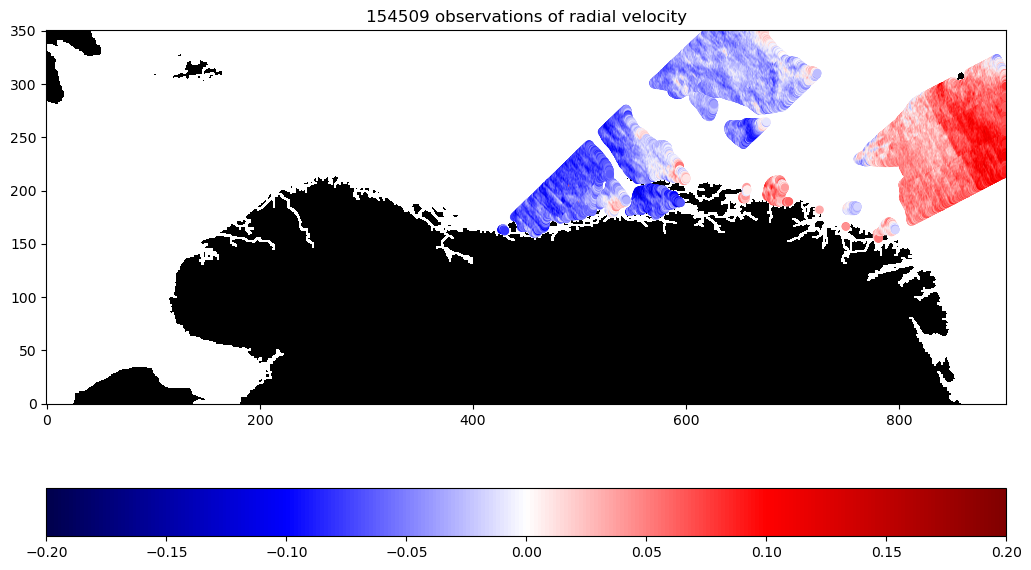

In [10]:
pyromsobs.plot_obs(SARobs, target_roms_domain,Vmin = -0.20, Vmax = 0.20, obstype=20)

## Examples of data thinning: 

The provided footprint is given as a radius in # of grid cells, and the choice is thus dependent on the resolution of the target model domain. 



Number of observations:  154509
Number of observations after thinning:  1440


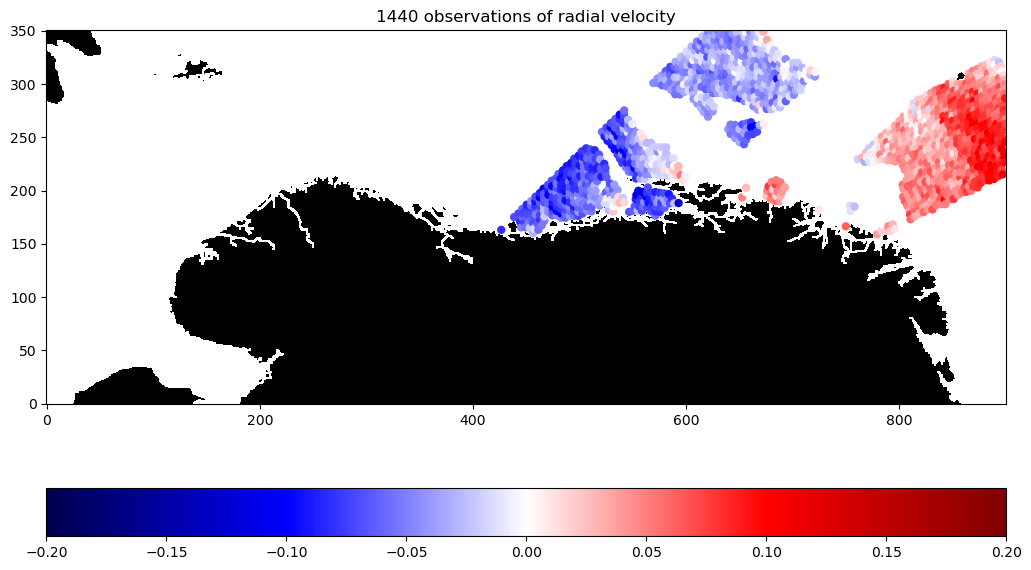

In [11]:
tmp = thinning(SARobs, footprint = 1, selection_variable="Xgrid") 
pyromsobs.plot_obs(tmp, target_roms_domain, Vmin = -0.20, Vmax = 0.20, obstype=20)



Number of observations:  154509
Number of observations after thinning:  675


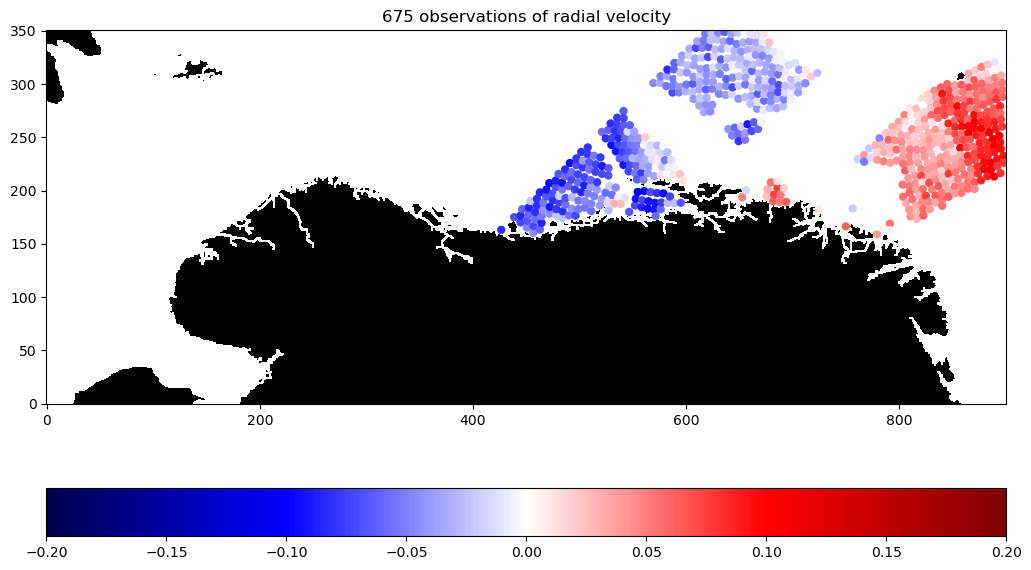

In [12]:
tmp = thinning(SARobs, footprint = 2, selection_variable="Xgrid") 
pyromsobs.plot_obs(tmp, target_roms_domain, Vmin = -0.20, Vmax = 0.20, obstype=20)

## Plot showing the bearing angle of the swaths: 

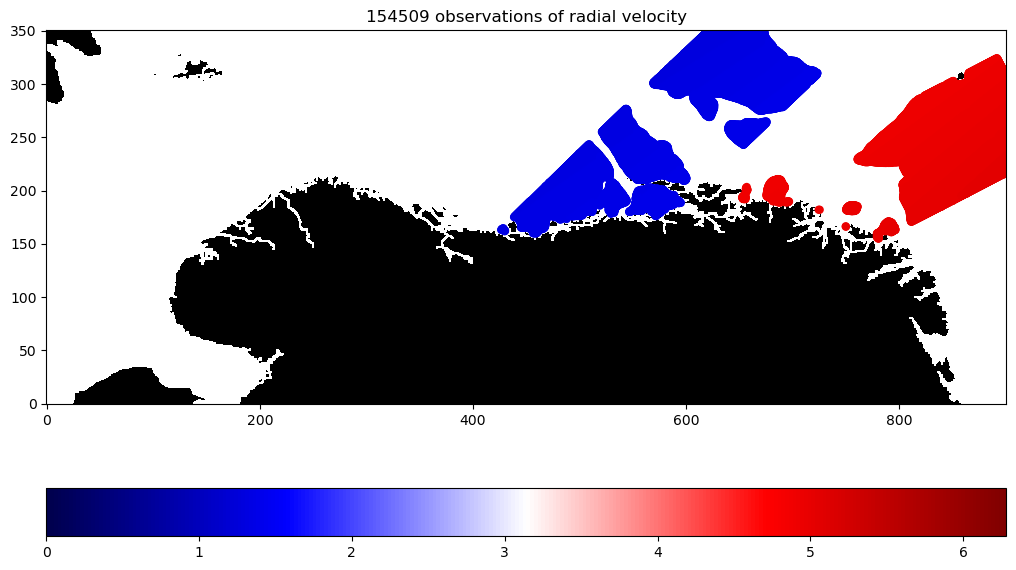

In [13]:
create_plot(SARobs, SARobs.meta, target_roms_domain, obstype = 20, vmin=0, vmax=2*np.pi)

In [2]:
def polygon_from_lonlat(lon, lat, proj):
    '''
    This function creates two polygon instances from 2D-matrices of longitude and latitude.
    
    1)  lon/lat coordinates,
    
    and
    
    2) in the projection specified by the argument proj 
    '''
    from shapely.geometry import Polygon, Point
    coordinates = []
    geocoordinates = []
    l,m = lon.shape
    for i in range(0,l,int(l/150)):
        j = 0
        x,y = xy_from_lonlat(proj,lon[i,j], lat[i,j] )
        coordinates.append([x,y])
        geocoordinates.append([lon[i,j], lat[i,j]])
    for j in range(0,m,int(m/150)):
        i = -1
        x,y = xy_from_lonlat(proj,lon[i,j], lat[i,j] )
        coordinates.append([x,y])
        geocoordinates.append([lon[i,j], lat[i,j]])

    for i in range(l-1,0,-int(l/150)):
        j = -1
        if i >= 0:
            x,y = xy_from_lonlat(proj,lon[i,j], lat[i,j] )
            coordinates.append([x,y])
            geocoordinates.append([lon[i,j], lat[i,j]])

    for j in range(m-1,0-int(m/150),-int(m/150)):
        i=0
        if j >= 0:
            x,y = xy_from_lonlat(proj,lon[i,j], lat[i,j] )
            coordinates.append([x,y])
            geocoordinates.append([lon[i,j], lat[i,j]])

    return Polygon(coordinates), Polygon(geocoordinates)

def polygon_from_ncdump(satfile, proj ):
    '''
    This function creates two polygon instances information found on the input file "satfile" (netcfd).
    
    1)  lon/lat coordinates,
    
    and
    
    2) in the projection specified by the argument proj 
    '''
    from shapely.geometry import Polygon, Point
    from subprocess import Popen
    p = Popen(['ncdump', '-h', satfile], stdout=PIPE, stderr = PIPE)
    polystr = None
    
    output = p.communicate()[0]
    northernmost = 0
    southernmost = 0
    easternmost = 0
    westernmost = 0

    for line in output.decode('UTF8').split('\n'):
        if 'POLYGON' in line:
            polystr = line        
            break

        if 'northernmost' in line:
            try:
                northernmost  = float(line.split('=')[-1].split('f')[0])
            except:
                northernmost  = float(line.split('=')[-1].split(';')[0])
        if 'southernmost' in line:
            try:
                southernmost  = float(line.split('=')[-1].split('f')[0])
            except:
                southernmost  = float(line.split('=')[-1].split(';')[0])

        if 'easternmost' in line:
            try:
                easternmost  = float(line.split('=')[-1].split('f')[0])
            except:
                easternmost  = float(line.split('=')[-1].split(';')[0])
        if 'westernmost' in line:
            try:
                westernmost  = float(line.split('=')[-1].split('f')[0])
            except:
                westernmost  = float(line.split('=')[-1].split(';')[0])
    if not polystr:
        # Construct a polygon from the box spanned by
        # westernmost, northernmost, easternmost and southernmost
        coordinates = []
        geocoordinates = []
        x,y = xy_from_lonlat(proj,westernmost, northernmost )
        coordinates.append([x,y])
        geocoordinates.append([westernmost, northernmost])
        x,y = xy_from_lonlat(proj,easternmost, northernmost )
        coordinates.append([x,y])
        geocoordinates.append([easternmost, northernmost])
        x,y = xy_from_lonlat(proj,easternmost, southernmost )
        coordinates.append([x,y])
        geocoordinates.append([easternmost, southernmost])
        x,y = xy_from_lonlat(proj,westernmost, southernmost )
        coordinates.append([x,y])
        geocoordinates.append([westernmost, southernmost])

        satpoly = Polygon(coordinates) # polygon in projection coordinates
        p360 = Polygon(geocoordinates) # polygon in geo coordinates

    else:
        # If the file has the polygon attribute, use this to construct test polygon
        mywkt = polystr.split('"')[1]
        test = mywkt.split('((')[1]
        test = test.split('))')[0]
        test = test.split(',')
        points = []
        newpoints = []
        for t in test:
            n =  float(t.split()[0])
            newpoints.append( (float(t.split()[1]), float(t.split()[0])))
            x,y =  xy_from_lonlat(proj , float(t.split()[1]), float(t.split()[0]) )

            points.append((x,y))
        satpoly = Polygon(points)
        p360 = Polygon(newpoints)
        
    return satpoly, p360

def xy_from_lonlat( proj, lon,lat):
    '''
    Calculates projection coordinates x,y in the specified projection.
    '''
    import numpy as np
    import cartopy.crs as ccrs
    try:
        print(len(lon))
    except:
        lon = np.array([lon])
        lat = np.array([lat])
    transform = proj.transform_points(ccrs.PlateCarree(), lon, lat)
    x = transform[..., 0]
    y = transform[..., 1]
    return x[0],y[0]

def Polygon_check(OBS, geopoly):
    '''
    Given an pyromsobs observation object, and a Polygon in lon/lat coordinates, 
    this function will discard all observations that fall outside the polygon. 
    '''
    from shapely.geometry import Polygon, Point
    import numpy as np
    print('Observation object initially filled with {} observations'.format(OBS.Ndatum))
    inside = np.empty(len(OBS.lon), dtype = object)
    for n in range(OBS.Ndatum):
        if geopoly.contains(Point(OBS.lon[n], OBS.lat[n])):
            inside[n] = True
        else:
            inside[n] = False
    OBS= OBS[np.where(inside)]
    
    print('After polygon check, {} observations are left'.format(OBS.Ndatum))
    return OBS

def roundTime(dt=None, roundTo=60):
    from datetime import datetime, timedelta
    """Round a datetime object to any time lapse in seconds
    dt : datetime.datetime object, default now.
    roundTo : Closest number of seconds to round to, default 1 minute.
    Author: Thierry Husson 2012 - Use it as you want but don't blame me.
    """
    if dt == None : dt = datetime.now()
    seconds = (dt.replace(tzinfo=None) - dt.min).seconds
    rounding = (seconds+roundTo/2) // roundTo * roundTo
    return dt + timedelta(0,rounding-seconds,-dt.microsecond)

def adjust_survey(obstime,obsref, minutes = 5):
    from datetime import datetime, timedelta
    import numpy as np
    timestamp = np.array([obsref + timedelta(days = float(t)) for t in obstime], dtype = datetime)
    timestamp = np.array([ roundTime(t, minutes*60) for t in timestamp], dtype = datetime)
    obstimes = np.array( [ np.round((t - obsref).total_seconds()) for t in timestamp] )
    return obstimes/86400.


def coordinate_matrix(gridfile):
    '''
    This function constructs matrices xi, yi with the indexes of each point. 
    These are usefull for speedy calculations of fractional grid coordinates, as needed by the ROMS 4D-Var algorithms.
    '''
    import xarray as xr
    import numpy as np
    with  xr.open_dataset(gridfile) as grid:

        x   = np.linspace(0, grid.lat_rho.values.shape[1]-1, grid.lat_rho.values.shape[1])
        y   = np.linspace(0, grid.lat_rho.values.shape[0]-1, grid.lat_rho.values.shape[0])
        xi  = np.zeros_like(grid.lon_rho.values)
        yi  = np.zeros([grid.lon_rho.values.shape[1], grid.lon_rho.values.shape[0]])
        xi[:,:] = x
        yi[:,:] = y
        yi  = np.swapaxes(yi, 1, 0)
    return xi, yi



In [3]:
def np_dt64_to_datetime(dt64):
    '''
    Conversion between numpy dt64 timeformat to datetime format.
    '''
    import numpy as np
    import datetime
    unix_epoch = np.datetime64(0, 's')
    one_second = np.timedelta64(1, 's')
    seconds_since_epoch = (dt64 - unix_epoch) / one_second
    
    return datetime.datetime.utcfromtimestamp(seconds_since_epoch)

In [4]:
def thinning(obs, footprint, selection_variable = 'error'):
    import pyromsobs 
    import numpy as np
    from datetime import datetime, timedelta
    footprint += 0.5

    new = []
    print('\n')
    print('Number of observations: ', obs.Ndatum)
    for s in obs.survey_time:
        workon = obs[np.where(obs.time == s)]
        n = 0
        while True:
            try:
                # this returns the index of the observation with the lowest value in starting_variable (default is observation error)
                ind = np.argpartition(getattr(workon, selection_variable), n)[n]
            except ValueError:
                # When n is larger than the number of observations left , there's no more data to thin.
                break

            # Now find indices of points that are more than 2 footprints away from this observation - these are the ones to keep.
            # 2*footprint as the other observations also have a footprint of the same size
            indices = list(np.where( ((workon.Xgrid <  workon.Xgrid[ind] - 2*(footprint + 0.5) ) | (workon.Xgrid >  workon.Xgrid[ind] + 2*(footprint + 0.5) ))  |  ((workon.Ygrid <  workon.Ygrid[ind] - 2*(footprint + 0.5)) | (workon.Ygrid >  workon.Ygrid[ind] + 2*(footprint + 0.5) ) )  )[0])
            indices.append(ind)      # add the observation with the lowest value of the selection_variable to the list of indices to keep              
            workon = workon[indices]
            n += 1
        
        # For some cases we could possibly have some areas left where the thinning was not successful. 
        # Add an extra thinning to ensure sufficient thinning. 
        if workon.Ndatum > 1:
            n = 0
            mindist = 0
            while mindist < 2*footprint:
                #print(mindist, workon.Ndatum)
                nobs = workon.Ndatum
                dist = np.ones_like(workon.Xgrid)*100000
            
                for m in range(workon.Ndatum):
                    dist[m] = np.sort(np.sqrt( (workon.Xgrid[m] - workon.Xgrid)**2 +  (workon.Ygrid[m] - workon.Ygrid)**2     ))[1]
                mindist = max(mindist, np.min(dist))
                if mindist >= 2*footprint:
                    break
                dist[np.where(dist < 2* footprint)] = dist[np.where(dist < 2* footprint)] * workon.error[np.where(dist < 2* footprint)]
                dist[np.where(dist >= 2* footprint)] = dist[np.where(dist >= 2* footprint)] *100000
                
                try:
                    # this returns the index of the observation with the smallest obs.error
                    ind = np.argsort(dist)[0]
                except ValueError:
                    # When n is larger than the number of observations left , there's no more data to thin.
                    break
                except IndexError:
                    # When n is larger than the number of observations left , there's no more data to thin.
                    break
                # Now find indices of points that are more than 2 footprints away from this obsrevations - these are the ones to keep.
                # 2*footprint as the other observations also have a footprint of the same size
                indices = list(np.where( ((workon.Xgrid <  workon.Xgrid[ind] - 2*(footprint + 0.5) ) | (workon.Xgrid >  workon.Xgrid[ind] + 2*(footprint + 0.5) ))  |  ((workon.Ygrid <  workon.Ygrid[ind] - 2*(footprint + 0.5)) | (workon.Ygrid >  workon.Ygrid[ind] + 2*(footprint + 0.5) ) )  )[0])
                indices.append(ind)      # add the observation with the smallest obs.error to the list of indices to keep              
                workon = workon[indices]
                
            n += 1

        new.append(workon)
    if len(new):
        new = pyromsobs.merge(new)

    print('Number of observations after thinning: ', new.Ndatum)
    return new

def create_plot(OBS, var, gridfile,  obstype = 9, vmin = -3, vmax = 3, figname = 'None'):
    import matplotlib.pyplot as plt
    import cmocean
    import xarray as xr
    
    grid = xr.open_dataset(target_roms_domain)
    xi, yi = coordinate_matrix(target_roms_domain)
    
    obstypes={1:{'name':'zeta','cmap': plt.cm.ocean}, 2:{'name':'ubar', 'cmap':plt.cm.seismic},
          3:{'name':'vbar', 'cmap':plt.cm.seismic}, 4:{'name':'u', 'cmap':plt.cm.seismic},
          5:{'name':'v', 'cmap':plt.cm.seismic}, 6:{'name':'temperature', 'cmap':plt.cm.plasma},
          7:{'name':'salinity', 'cmap':plt.cm.viridis}, 20:{'name':'radial velocity', 'cmap':plt.cm.seismic}, 
          9:{'name':'temp difference', 'cmap':cmocean.cm.balance}}
    fig=plt.figure(figsize=(12,7))
    ax = fig.add_axes([0.1, 0.15, 0.8, 0.8])
    plt.pcolormesh(xi, yi,grid.mask_rho.values, cmap='Greys_r')
    im=plt.scatter(OBS.Xgrid,OBS.Ygrid,c=var, vmin = vmin ,vmax = vmax, edgecolor='None',cmap=obstypes[obstype]['cmap'])
    plt.axis('image')
    if xi.shape[1] > xi.shape[0]:
     cbar=plt.colorbar(im, orientation='horizontal')
    else:
     cbar=plt.colorbar(im, orientation='vertical')
    plt.title(str(len(OBS.value))+' observations of '+obstypes[obstype]['name'])
    if figname != 'None':
        plt.savefig(figname)